# LCOH Results Analysis — EU Industrial Facilities

Exploratory analysis of `outputs/lcoh_results.csv`:

1. **Regional (country-level) summaries** — LCOH, prices, and least-cost pathway mix
2. **Electricity vs natural gas prices** — levels, ratios, and regional patterns
3. **Technology comparison** — heat pump, heat battery, and natural gas boiler LCOH

Data source: Eurostat industrial electricity (Band IC) and gas (Band I3) prices; LCOH per spec v1.3.1.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("..").resolve()
DATA_PATH = ROOT / "outputs" / "lcoh_results.csv"

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

PATHWAY_COLORS = {
    "natural_gas": "#4C72B0",
    "heat_pump": "#55A868",
    "heat_battery": "#C44E52",
}
LCOH_COLS = {
    "natural_gas": "lcoh_natural_gas_EUR_MWhth",
    "heat_pump": "lcoh_heat_pump_EUR_MWhth",
    "heat_battery": "lcoh_heat_battery_EUR_MWhth",
}
PATHWAY_LABELS = {
    "natural_gas": "Natural gas boiler",
    "heat_pump": "Heat pump",
    "heat_battery": "Heat battery",
}

In [5]:
raw = pd.read_csv(DATA_PATH)
df = raw[raw["verification_status"] == "COMPUTED"].copy()

df["elec_gas_ratio"] = df["elec_price_used_EUR_MWh"] / df["gas_price_used_EUR_MWh"]
df["heat_demand_GWh"] = df["annual_heat_demand_MWh_th"] / 1000

print(f"Total facilities in file: {len(raw):,}")
print(f"Facilities with computed LCOH: {len(df):,}")
print(f"Countries: {df['iso3_country'].nunique()}")
print(f"Analysis years: {sorted(df['analysis_year'].dropna().unique())}")
df.head(3)

Total facilities in file: 3,591
Facilities with computed LCOH: 1,759
Countries: 29
Analysis years: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,eprtr_facility_id,eprtr_facility_name,eprtr_country,iso3_country,analysis_year,eprtr_activity,eprtr_lat,eprtr_lon,process_heat_temp_band,process_heat_temp_C,...,least_cost_pathway,delta_vs_gas_hp_EUR_MWhth,delta_vs_gas_hb_EUR_MWhth,elec_price_used_EUR_MWh,gas_price_used_EUR_MWh,assumptions_used,verification_status,flags,elec_gas_ratio,heat_demand_GWh
1,UK.CAED/EW_EA-558.FACILITY,Wissington Sugar Factory EPR/BX2108IQ,United Kingdom,GBR,2019,8(b),52.551275,0.452083,low,NaN,...,natural_gas,34.604,132.386,153.95,30.630,"A1,A2,A3,A4,A5,A6,A7,A8,A9_hp,A9_hb,A9_gas,A10...",COMPUTED,NaN,5.026118,1211.11111
2,NL.EEA/4001.FACILITY,Clauscentrale,Netherlands,NLD,2014,1(c),51.154460,5.907180,mid,NaN,...,natural_gas,NaN,54.856,91.10,41.396,"A1,A2,A3,A4,A5,A6,A7,A8,A9_hp,A9_hb,A9_gas,A10...",COMPUTED,[HP_NOT_APPLICABLE_TEMPERATURE],2.200696,2103.89395
3,EE.KAUR.TTR/74.FACILITY,"Enefit Power AS, Balti Elektrijaam\n Enefit...",Estonia,EST,2024,1(c),59.352964,28.125815,mid,NaN,...,natural_gas,NaN,80.103,145.65,62.315,"A1,A2,A3,A4,A5,A6,A7,A8,A9_hp,A9_hb,A9_gas,A10...",COMPUTED,[HP_NOT_APPLICABLE_TEMPERATURE],2.337318,812.41667


## 1. Dataset overview

In [6]:
overview = pd.DataFrame({
    "Metric": [
        "Facilities with LCOH computed",
        "Total annual heat demand (TWh_th)",
        "Mean electricity price (EUR/MWh)",
        "Mean gas price (EUR/MWh)",
        "Mean elec/gas price ratio",
        "Mean LCOH — natural gas (EUR/MWh_th)",
        "Mean LCOH — heat battery (EUR/MWh_th)",
        "Mean LCOH — heat pump (EUR/MWh_th, low-temp only)",
    ],
    "Value": [
        f"{len(df):,}",
        f"{df['annual_heat_demand_MWh_th'].sum() / 1e6:.2f}",
        f"{df['elec_price_used_EUR_MWh'].mean():.1f}",
        f"{df['gas_price_used_EUR_MWh'].mean():.1f}",
        f"{df['elec_gas_ratio'].mean():.2f}",
        f"{df['lcoh_natural_gas_EUR_MWhth'].mean():.1f}",
        f"{df['lcoh_heat_battery_EUR_MWhth'].mean():.1f}",
        f"{df['lcoh_heat_pump_EUR_MWhth'].dropna().mean():.1f}",
    ],
})
overview

,Metric,Value
0,Facilities with LCOH computed,"1,759"
1,Total annual heat demand (TWh_th),2395.21
2,Mean electricity price (EUR/MWh),160.3
3,Mean gas price (EUR/MWh),62.2
4,Mean elec/gas price ratio,2.85
5,Mean LCOH — natural gas (EUR/MWh_th),80.7
6,Mean LCOH — heat battery (EUR/MWh_th),180.3
7,"Mean LCOH — heat pump (EUR/MWh_th, low-temp only)",79.3


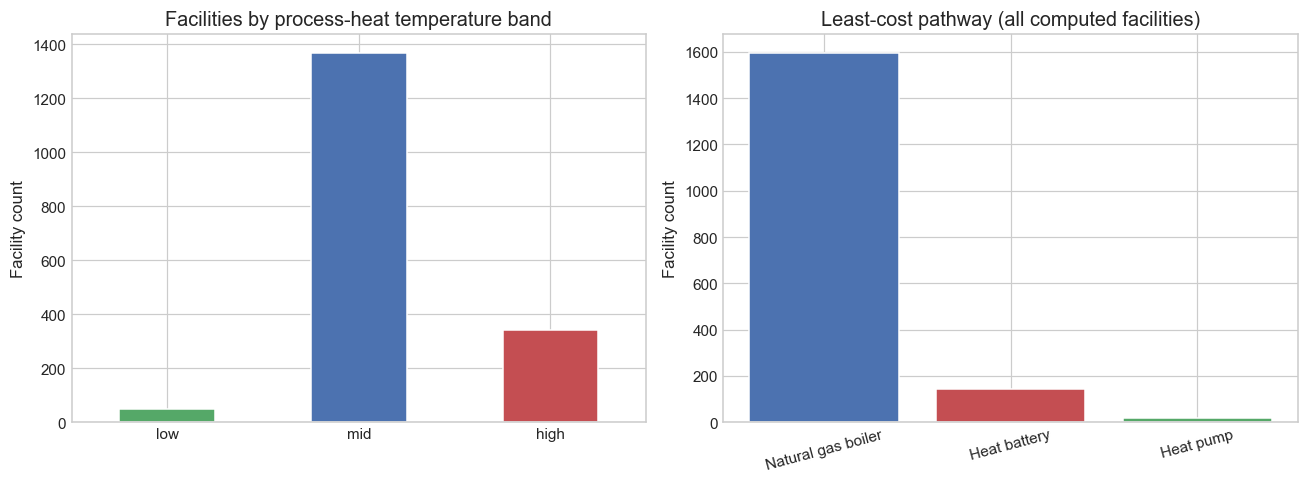

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

temp_counts = df["process_heat_temp_band"].value_counts().reindex(["low", "mid", "high"])
temp_counts.plot(kind="bar", ax=axes[0], color=["#55A868", "#4C72B0", "#C44E52"], edgecolor="white")
axes[0].set_title("Facilities by process-heat temperature band")
axes[0].set_xlabel("")
axes[0].set_ylabel("Facility count")
axes[0].tick_params(axis="x", rotation=0)

lc_counts = df["least_cost_pathway"].value_counts()
lc_counts.index = [PATHWAY_LABELS.get(x, x) for x in lc_counts.index]
colors = [PATHWAY_COLORS.get(k, "gray") for k in df["least_cost_pathway"].value_counts().index]
axes[1].bar(lc_counts.index, lc_counts.values, color=colors, edgecolor="white")
axes[1].set_title("Least-cost pathway (all computed facilities)")
axes[1].set_ylabel("Facility count")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 2. Regional (country) summaries

Aggregated by ISO3 country code. Heat-demand-weighted means show the economics for the bulk of industrial heat in each country.

In [9]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])


def country_summary(data):
    w = data["annual_heat_demand_MWh_th"]
    rows = []
    for iso, grp in data.groupby("iso3_country"):
        w_grp = grp["annual_heat_demand_MWh_th"]
        row = {
            "iso3_country": iso,
            "country_name": grp["eprtr_country"].mode().iloc[0],
            "n_facilities": len(grp),
            "heat_demand_TWh_th": w_grp.sum() / 1e6,
            "elec_price_mean": grp["elec_price_used_EUR_MWh"].mean(),
            "gas_price_mean": grp["gas_price_used_EUR_MWh"].mean(),
            "elec_gas_ratio_mean": grp["elec_gas_ratio"].mean(),
            "lcoh_gas_mean": grp["lcoh_natural_gas_EUR_MWhth"].mean(),
            "lcoh_hb_mean": grp["lcoh_heat_battery_EUR_MWhth"].mean(),
            "lcoh_hp_mean": grp["lcoh_heat_pump_EUR_MWhth"].mean(),
            "lcoh_gas_wtd": weighted_mean(grp["lcoh_natural_gas_EUR_MWhth"], w_grp),
            "lcoh_hb_wtd": weighted_mean(grp["lcoh_heat_battery_EUR_MWhth"], w_grp),
            "lcoh_hp_wtd": weighted_mean(grp["lcoh_heat_pump_EUR_MWhth"], w_grp),
            "n_hp_eligible": grp["lcoh_heat_pump_EUR_MWhth"].notna().sum(),
            "pct_least_cost_gas": (grp["least_cost_pathway"] == "natural_gas").mean() * 100,
            "pct_least_cost_hp": (grp["least_cost_pathway"] == "heat_pump").mean() * 100,
            "pct_least_cost_hb": (grp["least_cost_pathway"] == "heat_battery").mean() * 100,
        }
        rows.append(row)
    out = pd.DataFrame(rows).sort_values("heat_demand_TWh_th", ascending=False)
    return out


country_df = country_summary(df)
country_df.round(2)

,iso3_country,country_name,n_facilities,heat_demand_TWh_th,elec_price_mean,gas_price_mean,elec_gas_ratio_mean,lcoh_gas_mean,lcoh_hb_mean,lcoh_hp_mean,lcoh_gas_wtd,lcoh_hb_wtd,lcoh_hp_wtd,n_hp_eligible,pct_least_cost_gas,pct_least_cost_hp,pct_least_cost_hb
5,DEU,Germany,360,483.02,196.81,62.38,3.30,80.37,220.83,87.05,83.22,225.58,87.04,10,100.00,0.00,0.00
11,GBR,United Kingdom,136,332.72,140.16,31.26,4.53,40.10,157.89,72.22,40.39,165.81,75.40,4,100.00,0.00,0.00
16,ITA,Italy,149,274.56,203.86,57.25,3.69,75.51,228.66,112.06,78.40,233.92,102.14,2,99.33,0.67,0.00
7,ESP,Spain,119,227.57,138.05,51.09,2.82,69.82,155.54,65.68,78.26,165.78,65.68,1,100.00,0.00,0.00
22,POL,Poland,140,223.44,182.21,71.48,2.59,92.37,204.61,NaN,99.86,224.12,NaN,0,100.00,0.00,0.00
4,CZE,Czechia,67,139.87,146.07,67.67,2.27,90.32,164.46,45.41,105.32,182.74,45.41,1,100.00,0.00,0.00
21,NLD,Netherlands,88,98.24,138.26,53.67,2.53,68.08,155.78,60.91,71.71,163.76,66.48,5,98.86,1.14,0.00
10,FRA,France,169,93.68,155.40,67.92,2.26,88.07,174.82,83.34,95.10,190.51,86.69,15,91.72,8.28,0.00
12,GRC,Greece,29,69.81,172.77,50.81,3.43,70.57,194.12,NaN,74.61,195.98,NaN,0,100.00,0.00,0.00
2,BGR,Bulgaria,16,56.51,108.93,41.58,2.64,57.18,123.18,NaN,56.83,124.25,NaN,0,100.00,0.00,0.00


In [10]:
display_cols = [
    "iso3_country", "country_name", "n_facilities", "heat_demand_TWh_th",
    "elec_price_mean", "gas_price_mean", "elec_gas_ratio_mean",
    "lcoh_gas_wtd", "lcoh_hb_wtd", "lcoh_hp_wtd",
    "pct_least_cost_gas", "pct_least_cost_hp", "pct_least_cost_hb",
]
country_display = country_df[display_cols].copy()
country_display.columns = [
    "ISO3", "Country", "N facilities", "Heat demand (TWh_th)",
    "Elec price (EUR/MWh)", "Gas price (EUR/MWh)", "Elec/gas ratio",
    "LCOH gas (wtd)", "LCOH HB (wtd)", "LCOH HP (wtd)",
    "% least-cost gas", "% least-cost HP", "% least-cost HB",
]
country_display.round(1)

,ISO3,Country,N facilities,Heat demand (TWh_th),Elec price (EUR/MWh),Gas price (EUR/MWh),Elec/gas ratio,LCOH gas (wtd),LCOH HB (wtd),LCOH HP (wtd),% least-cost gas,% least-cost HP,% least-cost HB
5,DEU,Germany,360,483.0,196.8,62.4,3.3,83.2,225.6,87.0,100.0,0.0,0.0
11,GBR,United Kingdom,136,332.7,140.2,31.3,4.5,40.4,165.8,75.4,100.0,0.0,0.0
16,ITA,Italy,149,274.6,203.9,57.3,3.7,78.4,233.9,102.1,99.3,0.7,0.0
7,ESP,Spain,119,227.6,138.0,51.1,2.8,78.3,165.8,65.7,100.0,0.0,0.0
22,POL,Poland,140,223.4,182.2,71.5,2.6,99.9,224.1,NaN,100.0,0.0,0.0
4,CZE,Czechia,67,139.9,146.1,67.7,2.3,105.3,182.7,45.4,100.0,0.0,0.0
21,NLD,Netherlands,88,98.2,138.3,53.7,2.5,71.7,163.8,66.5,98.9,1.1,0.0
10,FRA,France,169,93.7,155.4,67.9,2.3,95.1,190.5,86.7,91.7,8.3,0.0
12,GRC,Greece,29,69.8,172.8,50.8,3.4,74.6,196.0,NaN,100.0,0.0,0.0
2,BGR,Bulgaria,16,56.5,108.9,41.6,2.6,56.8,124.2,NaN,100.0,0.0,0.0


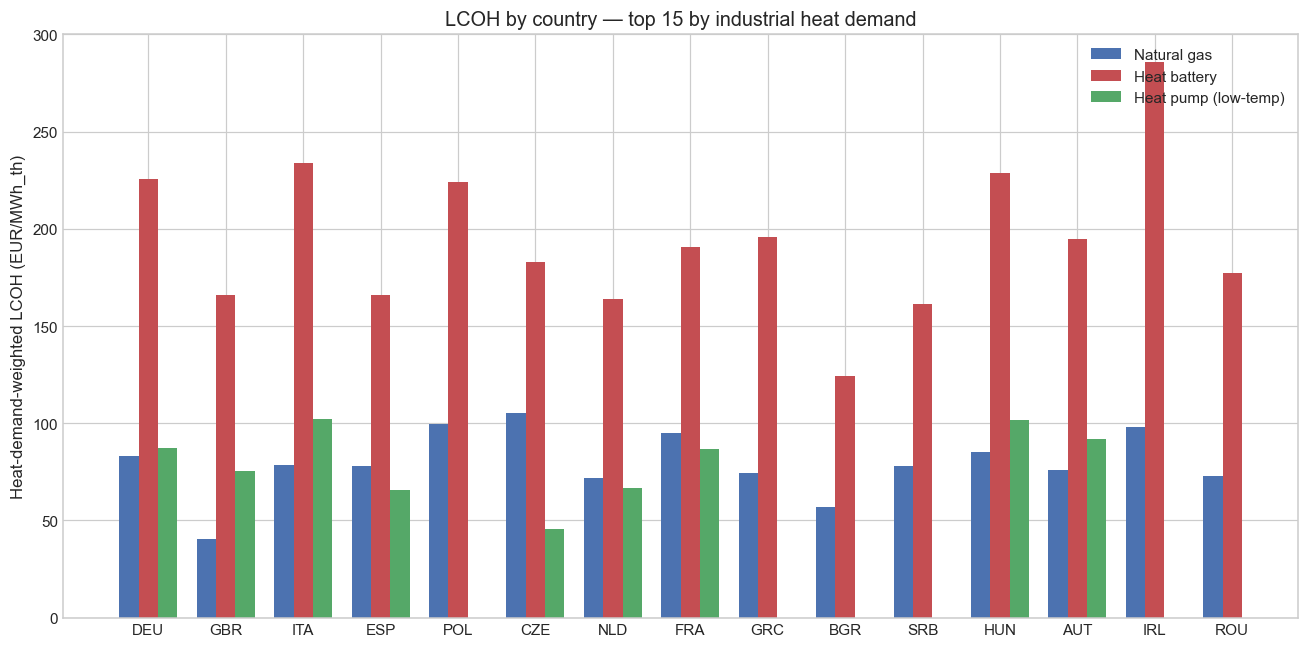

In [11]:
top_countries = country_df.nlargest(15, "heat_demand_TWh_th")

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top_countries))
width = 0.25

ax.bar(x - width, top_countries["lcoh_gas_wtd"], width, label="Natural gas", color=PATHWAY_COLORS["natural_gas"])
ax.bar(x, top_countries["lcoh_hb_wtd"], width, label="Heat battery", color=PATHWAY_COLORS["heat_battery"])
ax.bar(x + width, top_countries["lcoh_hp_wtd"], width, label="Heat pump (low-temp)", color=PATHWAY_COLORS["heat_pump"])

ax.set_xticks(x)
ax.set_xticklabels(top_countries["iso3_country"])
ax.set_ylabel("Heat-demand-weighted LCOH (EUR/MWh_th)")
ax.set_title("LCOH by country — top 15 by industrial heat demand")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 3. Electricity vs natural gas prices

Input energy prices (before technology conversion). Industrial electricity from Eurostat Band IC; gas from Band I3 (GCV→LHV adjusted).

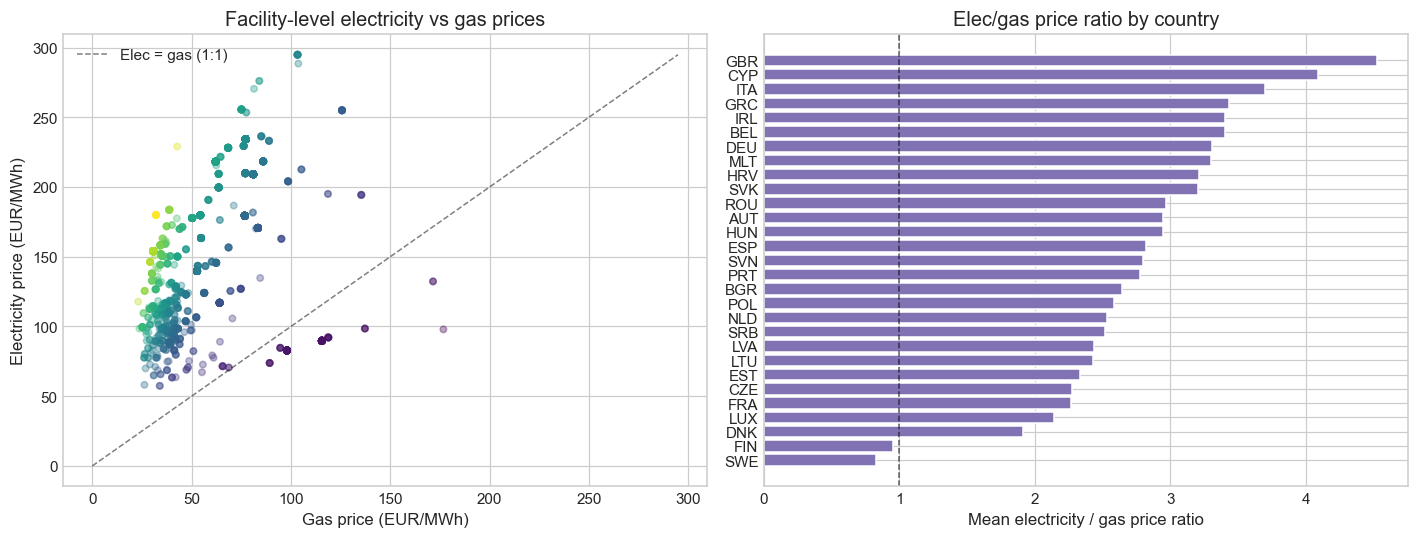

Overall elec/gas ratio — mean: 2.85, median: 2.77


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    df["gas_price_used_EUR_MWh"],
    df["elec_price_used_EUR_MWh"],
    alpha=0.35, s=18, c=df["elec_gas_ratio"], cmap="viridis",
)
max_p = max(df["elec_price_used_EUR_MWh"].max(), df["gas_price_used_EUR_MWh"].max())
axes[0].plot([0, max_p], [0, max_p], "k--", lw=1, alpha=0.5, label="Elec = gas (1:1)")
axes[0].set_xlabel("Gas price (EUR/MWh)")
axes[0].set_ylabel("Electricity price (EUR/MWh)")
axes[0].set_title("Facility-level electricity vs gas prices")
axes[0].legend()

country_prices = country_df.sort_values("elec_gas_ratio_mean", ascending=False)
y_pos = np.arange(len(country_prices))
axes[1].barh(y_pos, country_prices["elec_gas_ratio_mean"], color="#8172B3", edgecolor="white")
axes[1].axvline(1.0, color="k", ls="--", lw=1, alpha=0.6)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(country_prices["iso3_country"])
axes[1].invert_yaxis()
axes[1].set_xlabel("Mean electricity / gas price ratio")
axes[1].set_title("Elec/gas price ratio by country")

plt.tight_layout()
plt.show()

print(f"Overall elec/gas ratio — mean: {df['elec_gas_ratio'].mean():.2f}, median: {df['elec_gas_ratio'].median():.2f}")

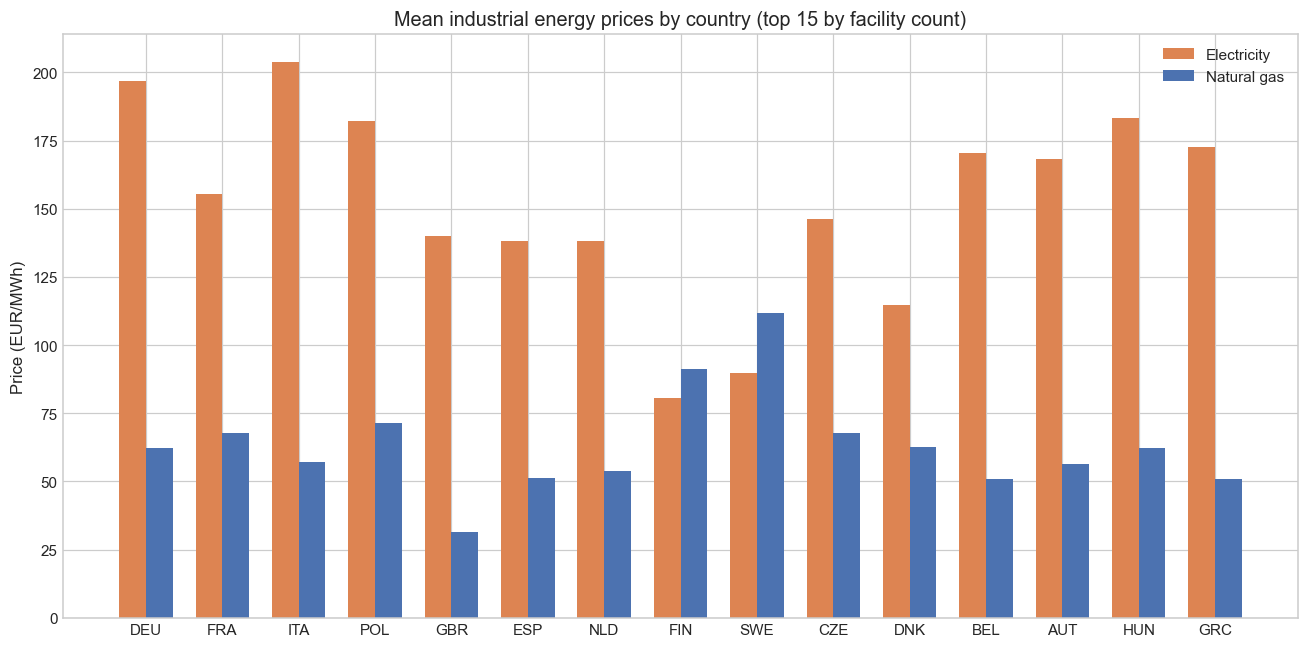

In [13]:
top15 = country_df.nlargest(15, "n_facilities")

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top15))
width = 0.35
ax.bar(x - width/2, top15["elec_price_mean"], width, label="Electricity", color="#DD8452")
ax.bar(x + width/2, top15["gas_price_mean"], width, label="Natural gas", color="#4C72B0")
ax.set_xticks(x)
ax.set_xticklabels(top15["iso3_country"])
ax.set_ylabel("Price (EUR/MWh)")
ax.set_title("Mean industrial energy prices by country (top 15 by facility count)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. LCOH comparison — heat pump, heat battery, natural gas

Levelized cost of heat includes annualized CAPEX, O&M, energy, and carbon costs. Heat pumps are only eligible for low-temperature processes (≤120 °C).

/var/folders/7b/k9t7lbq9461cdn3czk_fmvxm0000gn/T/ipykernel_9247/1090281274.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lcoh_long, x="pathway_label", y="lcoh_EUR_MWhth", order=order, palette=palette, ax=ax)


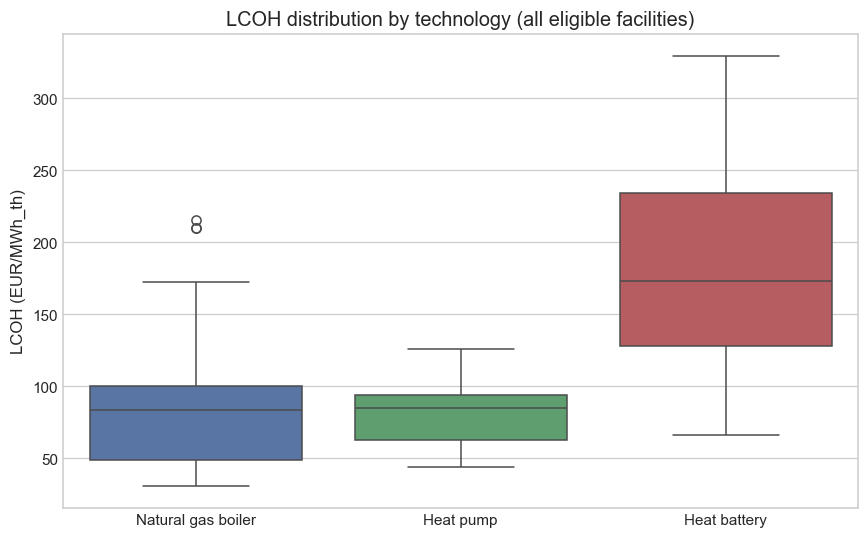

In [14]:
lcoh_long = df.melt(
    id_vars=["eprtr_facility_id", "iso3_country", "process_heat_temp_band", "least_cost_pathway"],
    value_vars=list(LCOH_COLS.values()),
    var_name="pathway_col",
    value_name="lcoh_EUR_MWhth",
).dropna(subset=["lcoh_EUR_MWhth"])

col_to_pathway = {v: k for k, v in LCOH_COLS.items()}
lcoh_long["pathway"] = lcoh_long["pathway_col"].map(col_to_pathway)
lcoh_long["pathway_label"] = lcoh_long["pathway"].map(PATHWAY_LABELS)

fig, ax = plt.subplots(figsize=(8, 5))
order = [PATHWAY_LABELS["natural_gas"], PATHWAY_LABELS["heat_pump"], PATHWAY_LABELS["heat_battery"]]
palette = [PATHWAY_COLORS["natural_gas"], PATHWAY_COLORS["heat_pump"], PATHWAY_COLORS["heat_battery"]]
sns.boxplot(data=lcoh_long, x="pathway_label", y="lcoh_EUR_MWhth", order=order, palette=palette, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("LCOH (EUR/MWh_th)")
ax.set_title("LCOH distribution by technology (all eligible facilities)")
plt.tight_layout()
plt.show()

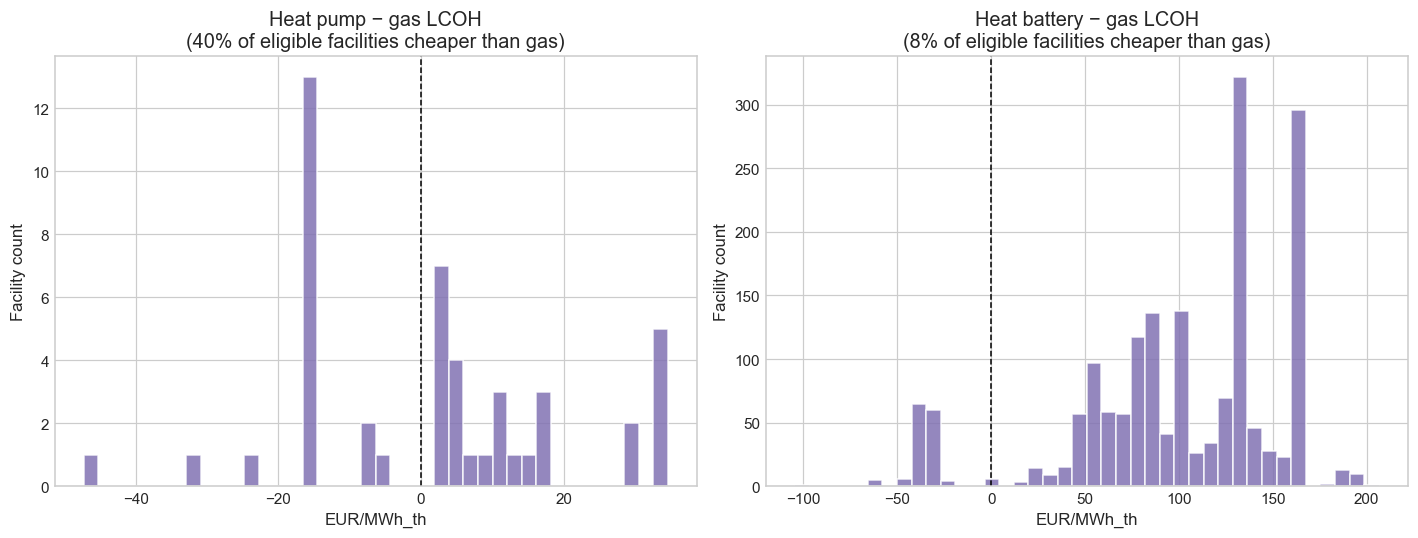

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in zip(
    axes,
    ["delta_vs_gas_hp_EUR_MWhth", "delta_vs_gas_hb_EUR_MWhth"],
    ["Heat pump − gas LCOH", "Heat battery − gas LCOH"],
):
    subset = df[df[col].notna()]
    ax.hist(subset[col], bins=40, color="#8172B3", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="k", ls="--", lw=1)
    cheaper = (subset[col] < 0).mean() * 100
    ax.set_xlabel("EUR/MWh_th")
    ax.set_ylabel("Facility count")
    ax.set_title(f"{label}\n({cheaper:.0f}% of eligible facilities cheaper than gas)")

plt.tight_layout()
plt.show()

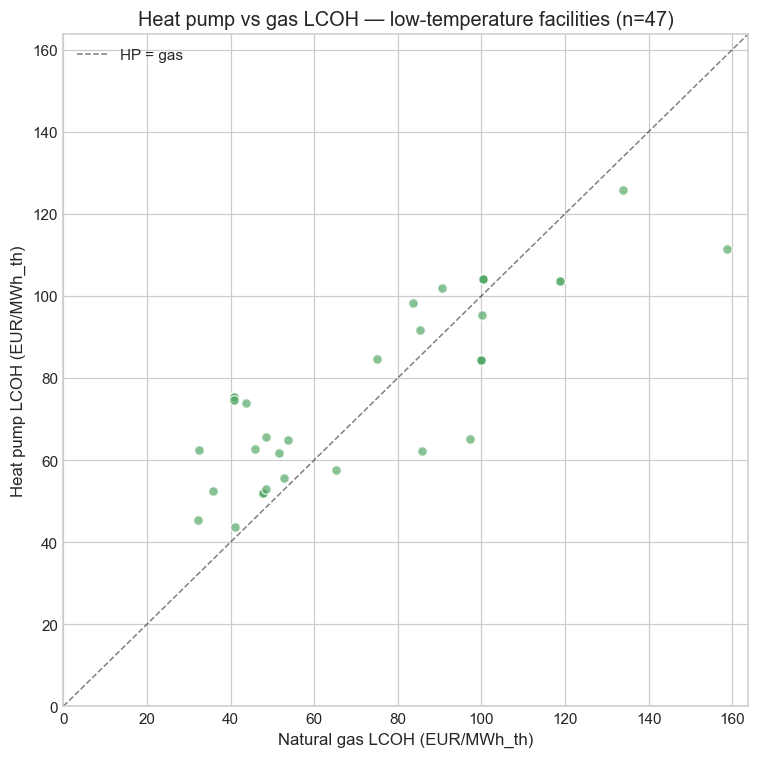

In [16]:
hp_df = df[df["lcoh_heat_pump_EUR_MWhth"].notna()].copy()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    hp_df["lcoh_natural_gas_EUR_MWhth"],
    hp_df["lcoh_heat_pump_EUR_MWhth"],
    alpha=0.7, s=40, c=PATHWAY_COLORS["heat_pump"], edgecolor="white",
)
lim = max(hp_df["lcoh_natural_gas_EUR_MWhth"].max(), hp_df["lcoh_heat_pump_EUR_MWhth"].max()) + 5
ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5, label="HP = gas")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Natural gas LCOH (EUR/MWh_th)")
ax.set_ylabel("Heat pump LCOH (EUR/MWh_th)")
ax.set_title(f"Heat pump vs gas LCOH — low-temperature facilities (n={len(hp_df)})")
ax.legend()
plt.tight_layout()
plt.show()

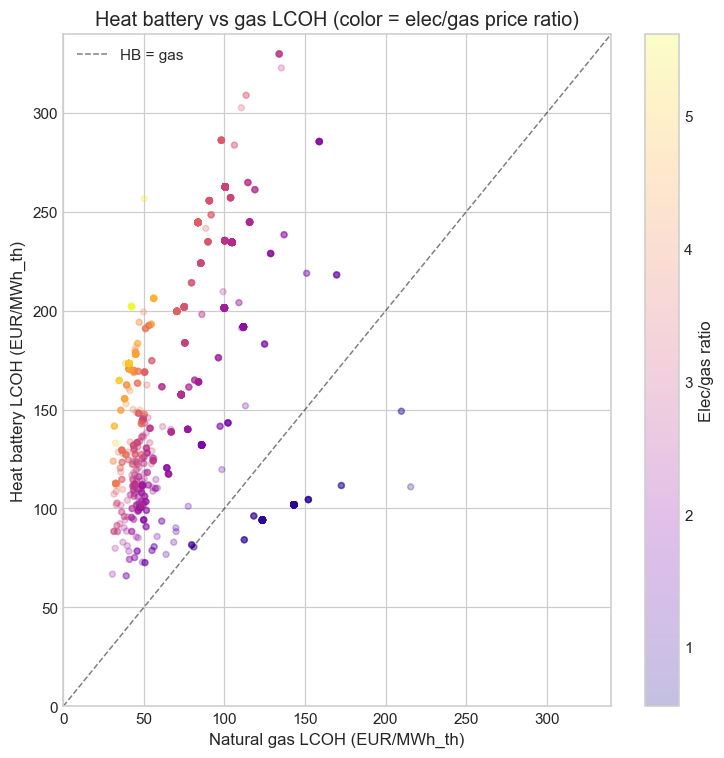

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    df["lcoh_natural_gas_EUR_MWhth"],
    df["lcoh_heat_battery_EUR_MWhth"],
    alpha=0.25, s=15, c=df["elec_gas_ratio"], cmap="plasma",
)
lim = max(df["lcoh_natural_gas_EUR_MWhth"].max(), df["lcoh_heat_battery_EUR_MWhth"].max()) + 10
ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5, label="HB = gas")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Natural gas LCOH (EUR/MWh_th)")
ax.set_ylabel("Heat battery LCOH (EUR/MWh_th)")
ax.set_title("Heat battery vs gas LCOH (color = elec/gas price ratio)")
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label("Elec/gas ratio")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Price drivers — how energy prices relate to LCOH

Electric pathways are more sensitive to electricity prices; gas LCOH tracks gas prices plus carbon.

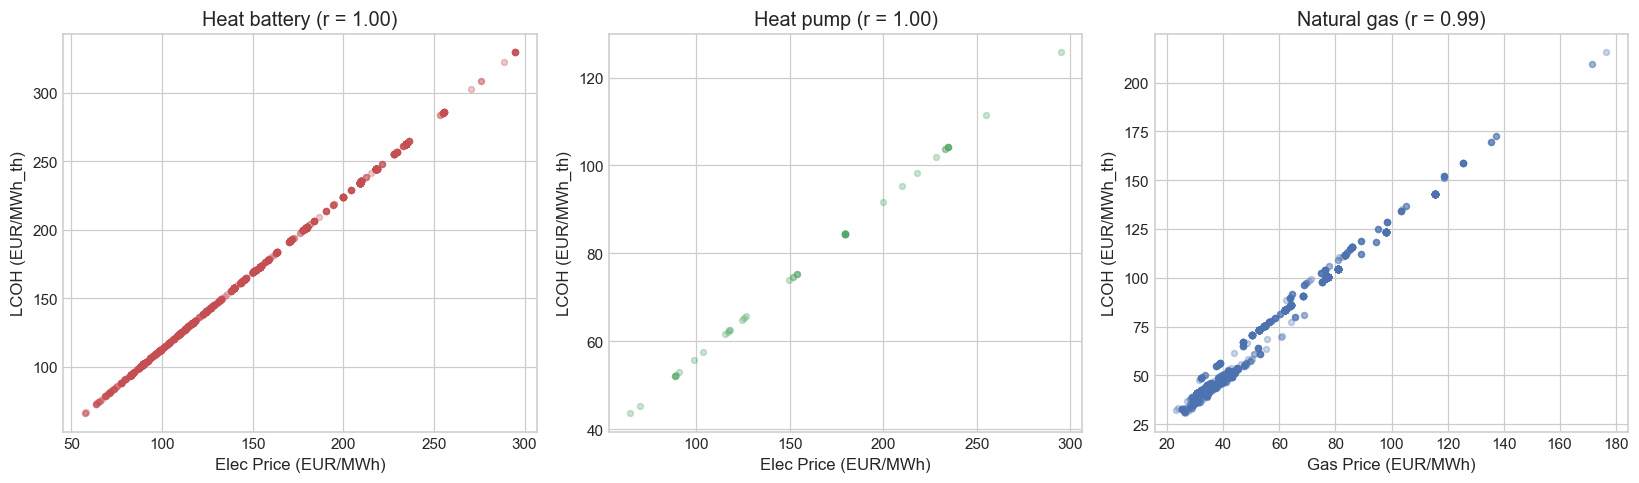

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pairs = [
    ("elec_price_used_EUR_MWh", "lcoh_heat_battery_EUR_MWhth", "Heat battery", PATHWAY_COLORS["heat_battery"]),
    ("elec_price_used_EUR_MWh", "lcoh_heat_pump_EUR_MWhth", "Heat pump", PATHWAY_COLORS["heat_pump"]),
    ("gas_price_used_EUR_MWh", "lcoh_natural_gas_EUR_MWhth", "Natural gas", PATHWAY_COLORS["natural_gas"]),
]

for ax, (xcol, ycol, title, color) in zip(axes, pairs):
    sub = df[[xcol, ycol]].dropna()
    ax.scatter(sub[xcol], sub[ycol], alpha=0.3, s=15, c=color)
    r = sub[xcol].corr(sub[ycol])
    ax.set_xlabel(xcol.replace("_used_EUR_MWh", "").replace("_", " ").title() + " (EUR/MWh)")
    ax.set_ylabel("LCOH (EUR/MWh_th)")
    ax.set_title(f"{title} (r = {r:.2f})")

plt.tight_layout()
plt.show()

## 6. Least-cost pathway by country and temperature band

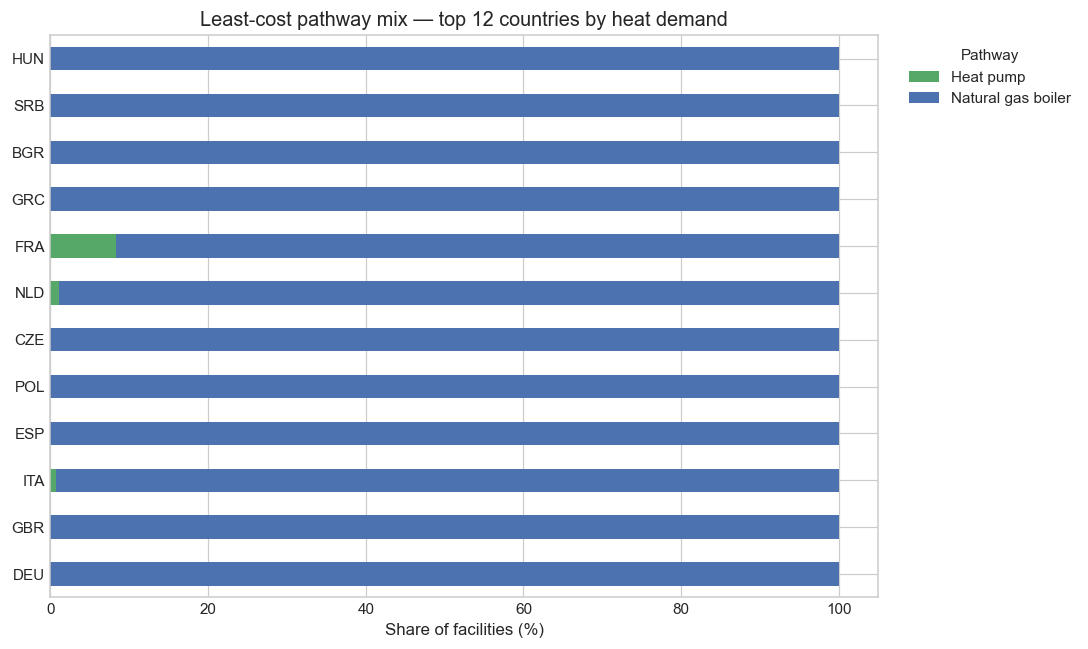

In [19]:
top12 = country_df.nlargest(12, "heat_demand_TWh_th")["iso3_country"]
lc_pivot = (
    df[df["iso3_country"].isin(top12)]
    .groupby(["iso3_country", "least_cost_pathway"])
    .size()
    .unstack(fill_value=0)
    .reindex(top12)
)
lc_pct = lc_pivot.div(lc_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
lc_pct.plot(kind="barh", stacked=True, ax=ax,
            color=[PATHWAY_COLORS.get(c, "gray") for c in lc_pct.columns])
ax.set_xlabel("Share of facilities (%)")
ax.set_ylabel("")
ax.set_title("Least-cost pathway mix — top 12 countries by heat demand")
ax.legend(title="Pathway", labels=[PATHWAY_LABELS.get(c, c) for c in lc_pct.columns], bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

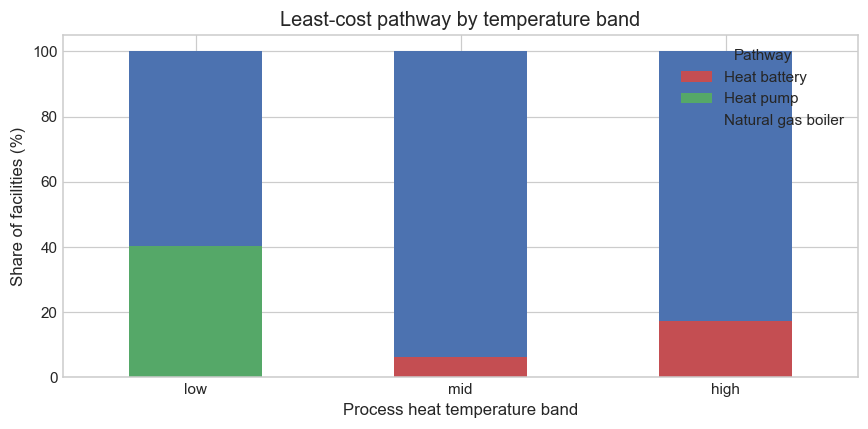

In [20]:
band_lc = (
    df.groupby(["process_heat_temp_band", "least_cost_pathway"])
    .size()
    .unstack(fill_value=0)
    .reindex(["low", "mid", "high"])
)
band_pct = band_lc.div(band_lc.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 4))
band_pct.plot(kind="bar", stacked=True, ax=ax,
              color=[PATHWAY_COLORS.get(c, "gray") for c in band_pct.columns])
ax.set_xlabel("Process heat temperature band")
ax.set_ylabel("Share of facilities (%)")
ax.set_title("Least-cost pathway by temperature band")
ax.legend(title="Pathway", labels=[PATHWAY_LABELS.get(c, c) for c in band_pct.columns])
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 7. Key takeaways

Run the cells above to populate numbers. At a glance from the workflow summary:

- **Natural gas** is the least-cost pathway for the majority of facilities (~91%), reflecting lower gas prices and competitive boiler economics even with carbon costs.
- **Heat pumps** are only eligible for low-temperature processes (47 facilities); where applicable, they can undercut gas in high elec/gas ratio markets.
- **Heat batteries** win in a subset of countries (143 facilities) where electricity prices are low relative to gas or gas+carbon costs are high.
- **Electricity prices** are typically **2–3× gas prices** on an energy basis, which drives the premium on electric heat pathways unless COP/efficiency and carbon costs shift the balance.